## First make a copy with your name to explore this Lab

# Analyzing Inventory to Make Decisions about movies to stock up on

What if we could use a supervised learning approach to better understand the properties of movies that are rented out a lot of times, and use that as a basis for stocking decisions. In this lab, we will create a data table by films i.e. each row will represent each film in the database. Film properties will be used to predict which films are more popular, and a target will be created based on films that are rented a lot.

Lets load our packages required for the analysis and load our database into R

In [3]:
install.packages("fpc")
install.packages("RMySQL")
install.packages("summarytools")

The following package(s) will be installed:
- fpc [2.2-13]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing fpc ...                            OK [linked from cache]
The following package(s) will be installed:
- RMySQL [0.11.0]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing RMySQL ...                         OK [linked from cache]
The following package(s) will be installed:
- summarytools [1.1.1]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing summarytools ...                   OK [linked from cache]


In [ ]:
library(ggplot2)
library(fpc)
library(tidyverse)
library(rpart)
library(rpart.plot)

mm <- src_mysql(
  host='[updateme]',
  port=3306,
  user='admin',
  password='[updateme]',
  dbname='dvdrental'
)

Warning message:
“`src_mysql()` was deprecated in dplyr 1.0.0.
ℹ Please use `tbl()` directly with a database connection”


First lets create our target variable, the number of times a film has been rented. We will get that information from the rental table, but we have to left join on the film table so that films that have not been rented will be included in our dataset.

In [5]:
# Write out a query and retrieve that table from the database
query <- "SELECT 
    f.title AS film_name,
    COUNT(distinct i.inventory_id) AS number_of_copies,
    COUNT(distinct r.rental_id) AS number_of_rentals
	FROM dvdrental.film f
	LEFT JOIN dvdrental.inventory i ON f.film_id = i.film_id
	LEFT JOIN dvdrental.rental r ON i.inventory_id = r.inventory_id
	GROUP BY f.title
	ORDER BY number_of_copies DESC, number_of_rentals DESC, f.title"

df1 <- tbl(mm, sql(query)) %>% collect() # Get data from the database
print(df1)

# A tibble: 1,000 × 3
   film_name           number_of_copies number_of_rentals
   <chr>                          <dbl>             <dbl>
 1 Bucket Brotherhood                 8                34
 2 Rocketeer Mother                   8                33
 3 Forward Temple                     8                32
 4 Grit Clockwork                     8                32
 5 Juggler Hardly                     8                32
 6 Ridgemont Submarine                8                32
 7 Scalawag Duck                      8                32
 8 Apache Divine                      8                31
 9 Goodfellas Salute                  8                31
10 Hobbit Alien                       8                31
# ℹ 990 more rows


Next, we're going to expand the table of film rental counts and add some film properties for use in a predictive model. 

In [6]:
# Write out a query and retrieve that table from the database
query <- "SELECT 
    f.title, c.name as category_name, f.release_year, f.language_id, f.rental_rate, 
    f.length, f.replacement_cost, f.rating, 
    COUNT(distinct r.staff_id) as no_staff_rented,
    COUNT(distinct i.inventory_id) as number_of_copies,
    COUNT(distinct i.store_id) as number_of_stores,
    COUNT(distinct r.rental_id) as times_rented,
    AVG(TIMESTAMPDIFF(HOUR, r.rental_date, r.return_date)) AS avg_actual_rental_length,
    f.rental_duration * 24 AS default_rental_length
    FROM film f
    LEFT JOIN inventory i ON f.film_id = i.film_id
    LEFT JOIN rental r ON i.inventory_id = r.inventory_id
	JOIN film_category fc ON f.film_id = fc.film_id
	JOIN category c ON fc.category_id = c.category_id
    GROUP BY f.film_id, c.name, f.title, f.release_year, f.language_id, f.rental_duration, f.rental_rate, 
    f.length, f.replacement_cost, f.rating
    ORDER BY number_of_copies DESC, times_rented DESC"

df4 <- tbl(mm, sql(query)) %>% collect() # Get data from the database
print(df4)

Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 4 imported as numeric”
Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 6 imported as numeric”
Warning message in dbSendQuery(conn, statement, ...):
“Decimal MySQL column 12 imported as numeric”
Warning message in dbSendQuery(con, sql):
“Decimal MySQL column 4 imported as numeric”
Warning message in dbSendQuery(con, sql):
“Decimal MySQL column 6 imported as numeric”
Warning message in dbSendQuery(con, sql):
“Decimal MySQL column 12 imported as numeric”


# A tibble: 1,000 × 14
   title               category_name release_year language_id rental_rate length
   <chr>               <chr>                <int>       <int>       <dbl>  <int>
 1 Bucket Brotherhood  Travel                2006           1           5    133
 2 Rocketeer Mother    Foreign               2006           1           1    178
 3 Forward Temple      Games                 2006           1           3     90
 4 Grit Clockwork      Games                 2006           1           1    137
 5 Juggler Hardly      Animation             2006           1           1     54
 6 Ridgemont Submarine New                   2006           1           1     46
 7 Scalawag Duck       Music                 2006           1           5    183
 8 Apache Divine       Family                2006           1           5     92
 9 Goodfellas Salute   Sci-Fi                2006           1           5     56
10 Hobbit Alien        Drama                 2006           1           1    157
# ℹ 9

Now we have a dataframe we can import into R to work on a decision tree. But first we have to create a target variable, a boolean indicating whether the film has been rented or not.

In [7]:
head(df4)

title,category_name,release_year,language_id,rental_rate,length,replacement_cost,rating,no_staff_rented,number_of_copies,number_of_stores,times_rented,avg_actual_rental_length,default_rental_length
<chr>,<chr>,<int>,<int>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Bucket Brotherhood,Travel,2006,1,5,133,28,PG,2,8,2,34,118.2059,168
Rocketeer Mother,Foreign,2006,1,1,178,28,PG-13,2,8,2,33,128.7576,72
Forward Temple,Games,2006,1,3,90,26,NC-17,2,8,2,32,133.7188,144
Grit Clockwork,Games,2006,1,1,137,22,PG,2,8,2,32,127.7500,72
Juggler Hardly,Animation,2006,1,1,54,15,PG-13,2,8,2,32,131.7419,96
Ridgemont Submarine,New,2006,1,1,46,29,PG-13,2,8,2,32,143.8065,72


In [8]:
# We are going to create a class variable for our target, popular or not popular. We define a popular movie as having been rented more than ten times.

df4$popular <- ifelse(df4$times_rented > 10, 1, 0)

# We are going to cast the variable 'popular' into a logical TRUE OR FALSE variable for simplicity and clarity of the output
df4$popular <- as.logical(df4$popular)

summary(df4)

    title           category_name       release_year   language_id
 Length:1000        Length:1000        Min.   :2006   Min.   :1   
 Class :character   Class :character   1st Qu.:2006   1st Qu.:1   
 Mode  :character   Mode  :character   Median :2006   Median :1   
                                       Mean   :2006   Mean   :1   
                                       3rd Qu.:2006   3rd Qu.:1   
                                       Max.   :2006   Max.   :1   
                                                                  
  rental_rate       length      replacement_cost    rating         
 Min.   :1.00   Min.   : 46.0   Min.   :10.00    Length:1000       
 1st Qu.:1.00   1st Qu.: 80.0   1st Qu.:15.00    Class :character  
 Median :3.00   Median :114.0   Median :20.00    Mode  :character  
 Mean   :2.99   Mean   :115.3   Mean   :19.99                      
 3rd Qu.:5.00   3rd Qu.:149.2   3rd Qu.:25.00                      
 Max.   :5.00   Max.   :185.0   Max.   :30.00           

Next we will create our decision tree.


In [9]:
library(ggplot2)
library(tidyverse)
library(rpart)
library(rpart.plot)

In [10]:
decision_tree_model <- rpart(popular ~ category_name + release_year + language_id + rental_rate + length + replacement_cost + rating + no_staff_rented + number_of_copies + number_of_stores,data=df4, method = "class")

In [11]:
df4$pred <- predict(decision_tree_model, type="class")


In [12]:
confusion_matrix <- df4 %>% count(popular,pred) %>% pivot_wider(names_from=popular,values_from=n)
confusion_matrix %>% knitr::kable(col.names=c('Prediction','Actual: Not Popular','Actual: Popular'))



|Prediction | Actual: Not Popular| Actual: Popular|
|:----------|-------------------:|---------------:|
|FALSE      |                 226|              21|
|TRUE       |                  20|             733|

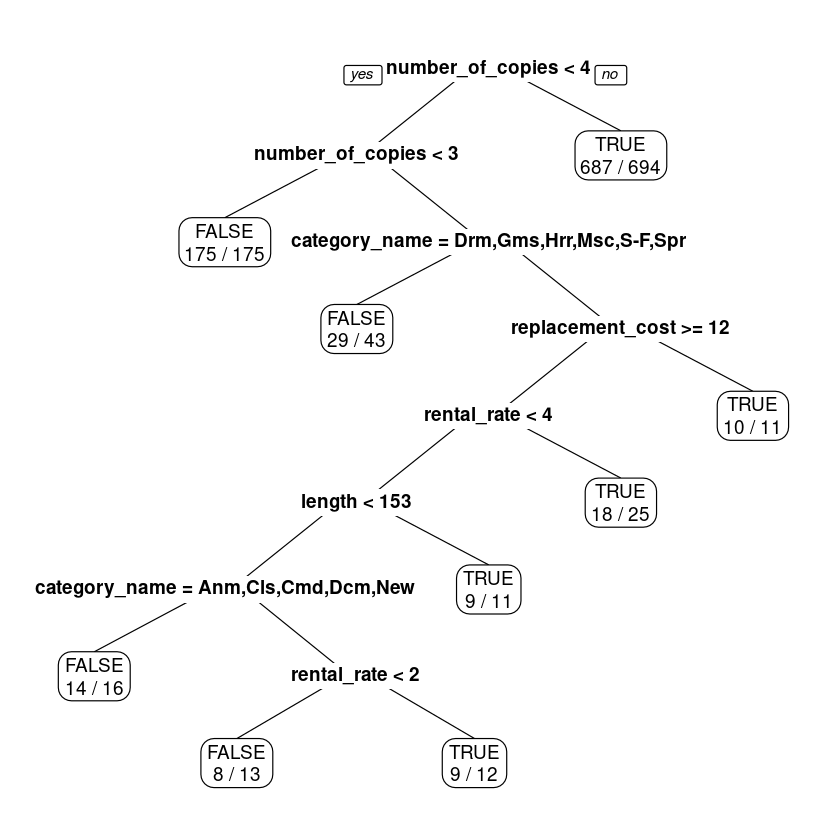

In [13]:
prp(decision_tree_model, varlen = 0, extra = 2) 

#note that after telling you which branch direction is yes, and which is no, you are to assume that for the remaining branches. i.e. left branches are all yes to the criteria, and right branches are all no.


## Revisit the code above and change the definition of popular

Try a different definition of popular. We have popular as a movie rented more than ten times. What if we change the value from 10 to 15? Does that change the results? You can edit the code below to see the outcome.




|Prediction | Actual: Not Popular| Actual: Popular|
|:----------|-------------------:|---------------:|
|FALSE      |                 442|              47|
|TRUE       |                  29|             482|

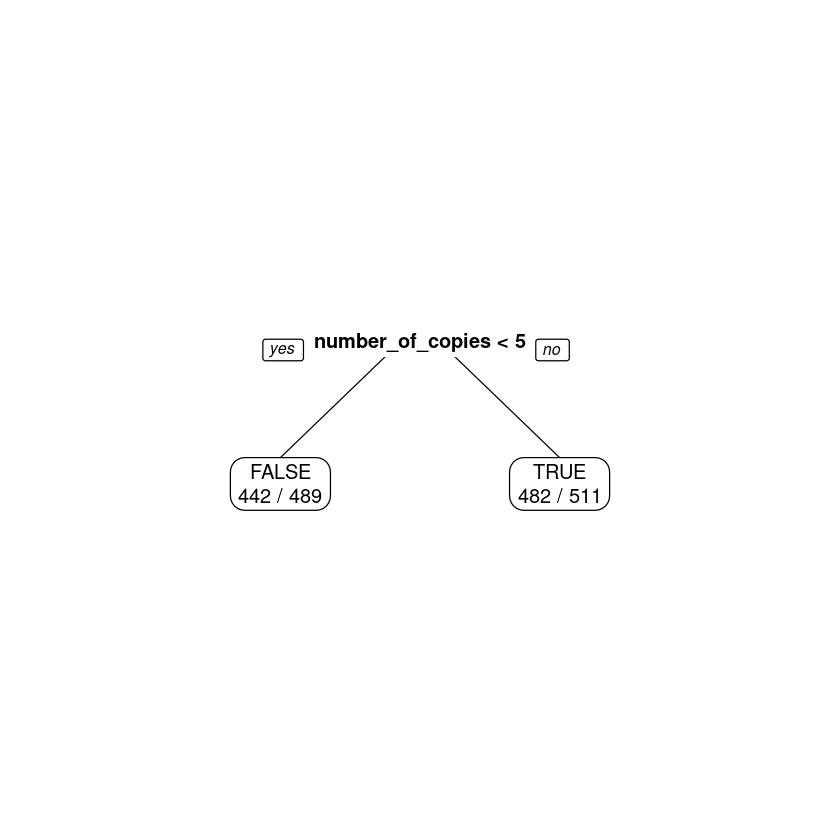

In [14]:
# Redefine a popular movie as having been rented more than fifteen times. Edit the code below.

df4$popular_2 <- ifelse(df4$times_rented > 15, 1, 0)

# We are going to cast the variable 'popular' into a logical TRUE OR FALSE variable for simplicity and clarity of the output
df4$popular_2 <- as.logical(df4$popular_2)

decision_tree_model_2 <- rpart(popular_2 ~ category_name + release_year + language_id + rental_rate + length + replacement_cost + rating + no_staff_rented + number_of_copies + number_of_stores,data=df4, method = "class")

df4$pred_2 <- predict(decision_tree_model_2, type="class")

confusion_matrix <- df4 %>% count(popular_2,pred_2) %>% pivot_wider(names_from=popular_2,values_from=n)
confusion_matrix %>% knitr::kable(col.names=c('Prediction','Actual: Not Popular','Actual: Popular'))

prp(decision_tree_model_2, varlen = 0, extra = 2) 



## Questions to think about

- Who should be responsible for setting the cutoff of such a definition for the organization?
- Can you think of another way to measure popularity for each film purchased? It doesn't have to be using data currently available, just another approach for measuring popularity.